# IMPORT REQUIRED LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# LOAD DATASET

In [2]:
github_url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML-Svl/refs/heads/main/dataset/diabetes%20(1).csv"
df = pd.read_csv(github_url)

print(df.head())
print(df.info())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

# SPLIT FEATURES AND TARGET

In [3]:
target_column = "Outcome"

X = df.drop(target_column, axis=1)
y = df[target_column]

# TRAIN TEST SPLIT

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# FEATURE SCALING (IMPORTANT FOR ANN)

In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Done")

Scaling Done


# BASE ANN MODEL

In [6]:
ann = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

ann.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)

# PREDICTIONS


In [7]:
y_pred = ann.predict(X_test_scaled)
y_pred_proba = ann.predict_proba(X_test_scaled)[:, 1]

# EVALUATION METRICS

In [8]:
print("\nEvaluation Metrics:\n")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Evaluation Metrics:

Accuracy : 0.7142857142857143
Precision: 0.5925925925925926
Recall   : 0.5925925925925926
F1 Score : 0.5925925925925926
AUC Score: 0.8157407407407408

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.78      0.78       100
           1       0.59      0.59      0.59        54

    accuracy                           0.71       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.71      0.71      0.71       154



# CONFUSION MATRIX

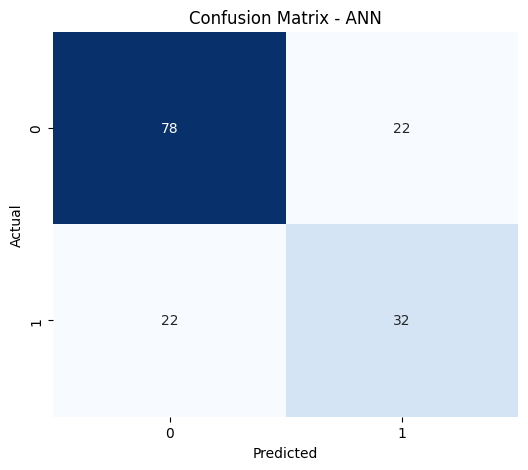

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC CURVE

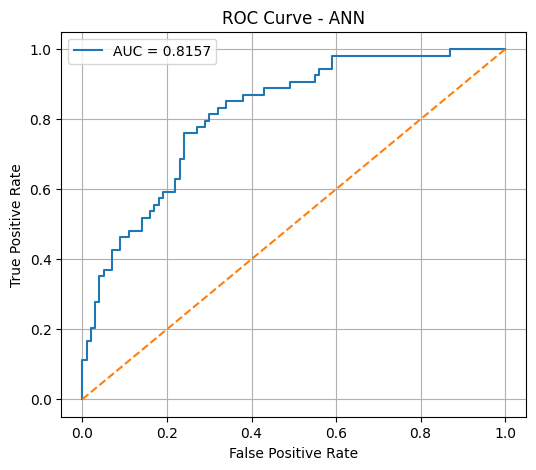

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - ANN")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# HYPERPARAMETER TUNING (GRID SEARCH)

In [17]:
param_grid = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (16, 8), (32, 16)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

grid = GridSearchCV(
    MLPClassifier(max_iter=500, random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.001}
Best CV Score: 0.7720378515260562


# BEST MODEL

In [13]:
best_ann = grid.best_estimator_
best_ann.fit(X_train_scaled, y_train)

y_pred = best_ann.predict(X_test_scaled)
y_pred_proba = best_ann.predict_proba(X_test_scaled)[:, 1]

# FINAL METRICS

In [14]:
print("\nFINAL MODEL RESULTS:\n")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_proba))


FINAL MODEL RESULTS:

Accuracy : 0.7597402597402597
Precision: 0.6666666666666666
Recall   : 0.6296296296296297
F1 Score : 0.6476190476190476
AUC Score: 0.8175925925925926


# SAMPLE PREDICTIONS TABLE

In [15]:
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Prob_No_Diabetes": best_ann.predict_proba(X_test_scaled)[:, 0],
    "Prob_Diabetes": best_ann.predict_proba(X_test_scaled)[:, 1],
    "Correct": y_test.values == y_pred
})

print(pred_df.head(15))

    Actual  Predicted  Prob_No_Diabetes  Prob_Diabetes  Correct
0        0          1          0.445296       0.554704    False
1        0          0          0.755318       0.244682     True
2        0          0          0.763955       0.236045     True
3        1          0          0.662606       0.337394    False
4        0          0          0.982672       0.017328     True
5        0          0          0.831948       0.168052     True
6        1          1          0.441594       0.558406     True
7        1          1          0.228759       0.771241     True
8        0          0          0.950413       0.049587     True
9        0          1          0.183743       0.816257    False
10       0          0          0.723764       0.276236     True
11       1          1          0.402270       0.597730     True
12       0          0          0.933296       0.066704     True
13       0          0          0.873540       0.126460     True
14       1          0          0.736190 

# END

In [16]:
print("\nANN Diabetes Classification Completed Successfully!")


ANN Diabetes Classification Completed Successfully!
